# Система поиска подходящих товаров на основе дообученной CLIP модели

## Описание проекта
**Цель:** разработать систему интеллектуального поиска одежды для крупного международного онлайн-магазина. 

## План 

### Этап 1. Fine-tuning модели CLIP
1. **Работа с данными:**
   * Загрузка датасета с Kaggle и визуализация случайных товаров.
   * Анализ качества и соответствия текстовых описаний (`description`) исходным картинкам (`image`).
   * Предобработка: очистка от дубликатов и пропусков (NaN).
   * Разделение выборки на Train и Test в соотношении **90% / 10%**.
   * Реализация кастомного класса `Dataset` (PyTorch) для загрузки и токенизации пар «изображение-текст».
2. **Работа с моделью:**
   * Загрузка предобученной модели (`openai/clip-vit-base-patch32`).
   * Проверка базового CLIP-score на нескольких сырых примерах.
3. **Дообучение (Fine-tuning):**
   * Реализация цикла обучения со стандартным Contrastive Loss для CLIP.
   * Написание функции валидации для оценки среднего CLIP-score на тестовой выборке в конце каждой эпохи.
   * Обучение модели в течение 3–4 эпох с сохранением промежуточных чекпоинтов (checkpoints).
   * Отрисовка графиков: кривая Loss, CLIP-score на Train и CLIP-score на Validation.
   * **Целевой показатель:** средний CLIP-score на валидации должен быть **выше 30**.

### Этап 2. Реализация системы поиска товаров
1. **Предрасчет эмбеддингов (Pre-computation):**
   * Загрузка лучшего чекпоинта дообученной модели.
   * Прогон всей базы картинок через энкодер изображений CLIP для получения векторов.
   * Сохранение матрицы эмбеддингов для мгновенного поиска (без пересчета картинок при каждом запросе).
2. **Создание поискового движка:**
   * Написание функции поиска, принимающей на вход текстовый запрос, модель, базу эмбеддингов и параметр $K$ (количество результатов).
   * Перевод текстового запроса пользователя в вектор через текстовый энкодер CLIP.
   * Расчет косинусного сходства между вектором запроса и эмбеддингами всех картинок.
   * Возврат и визуализация $K$ наиболее релевантных изображений.
3. **Тестирование:**
   * Проверка работы системы на контрольных запросах.

## Этап 0. Настройка окружения

In [1]:
# Загрузка библиотек

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import CLIPModel, CLIPProcessor

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Проверка доступности GPU 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


In [3]:
# Установка seed для воспроизводимости

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()

## Этап 1. Fine-tuning CLIP


## 1. Работа с данными

### 1.1 Загрузка данных

In [4]:
import kagglehub

path = kagglehub.dataset_download('nirmalsankalana/fashion-product-text-images-dataset')
print(f'Путь к датасету: {path}')

Путь к датасету: /home/ubuntu/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1


In [5]:
csv_path = os.path.join(path, 'data.csv')
img_dir = os.path.join(path, 'data')

In [6]:
# Проверяем доступность данных

try:
    df = pd.read_csv(csv_path)
    
    if not os.path.exists(img_dir):
        raise FileNotFoundError
        
    print('Данные успешно загружены.')

except:
    print('Данные не найдены по указанному пути.')
    sys.exit(1) 

Данные успешно загружены.


In [7]:
# Посмотри на данные

df.head()


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags
3,8141.jpg,"Perfectly stylish, this fastrack analog wrist ...",Fastrack Women Freestyle Sports Analog Steel B...,Watches
4,22245.jpg,These id mid-top chukka shoes add a fresh spin...,ID Men Brown Casual Shoes,Casual Shoes


In [8]:
print(f'\nРазмер датасета: {len(df)} записей\n')

df.info()


Размер датасета: 44441 записей

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image         44441 non-null  object
 1   description   44160 non-null  object
 2   display name  44434 non-null  object
 3   category      44441 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


В загруженном датасете 4 столбца: image, description, dispaly name, category. Всего 44441 записей. Все колонки имеют тип object. Столбцы description и display name имеют меньшее количество записей, что говорит о пропусках.

### 1.2 Предобработка данных

#### Обработка пропусков

In [9]:
# Посчитаем пропуски

df.isna().sum()

image             0
description     281
display name      7
category          0
dtype: int64

In [10]:
# Удаляем пропуски

df = df.dropna()

In [11]:
# Повторная проверка

df.isna().sum()

image           0
description     0
display name    0
category        0
dtype: int64

#### Обработка дубликатов

In [12]:
print(f'\nДубликаты: {df.duplicated().sum()}')


Дубликаты: 0


In [13]:
df = df.reset_index(drop=True)

In [14]:
print(f'Размер датасета после очистки: {len(df)}')

Размер датасета после очистки: 44160


### 1.3 EDA

Пример 1 (53879.jpg):
Описание: Black flip flops with thong style fabric straps in brown and a fabric toe separator Printed branding on the footbed TPU outsole with wave patterned grooves

Пример 2 (3953.jpg):
Описание: Composition Red scoop neck t-shirt made of 100% cotton, with graphic print on the front Wash care 1. Wash dark colours separately 2. Use mild detergent in warm water (maximum 40 degrees) 3. Do not wring or bleach 4. Flat dry in shade 5. Do not iron on print Fitting Regular Fit It is time to indulge in sweet thoughts and wish peace on earth with this red tee from jealous 21. The graphic of the girl in the front with the "Peace" banner with the horns and the "Angel" signature with the pointy tail all have bits of the devil in it - just to show that all good girls have a bit of the bad girl in them. Team this with faded jeans, shorts or a super cute denim mini skirt and stylish footwear from myntra's wide catalogue for that instant cool. Model's statistics 1. The model wea

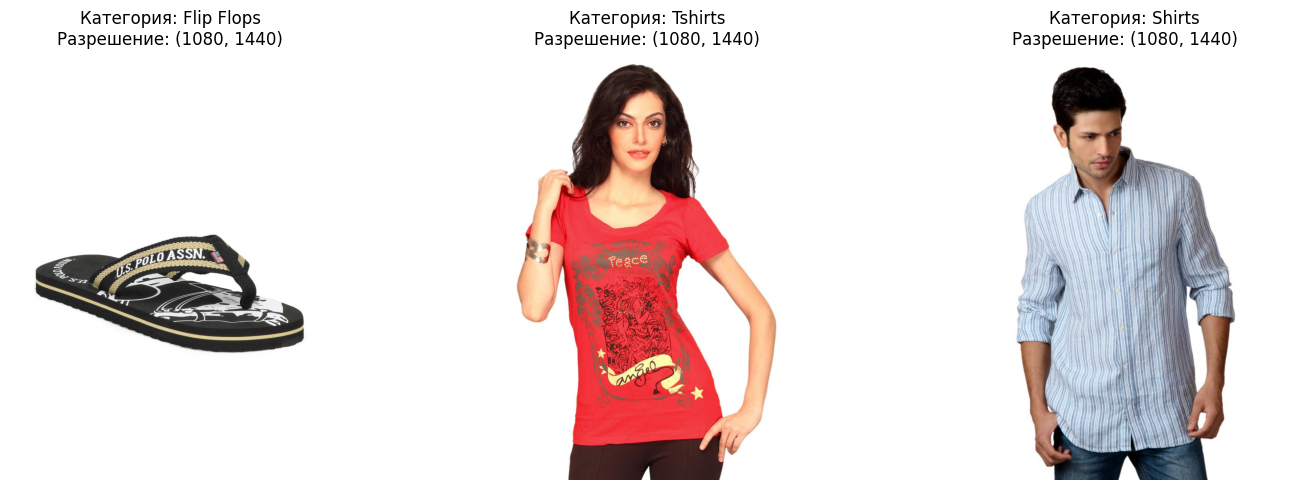

Размер обучающей выборки: 39744, Валидационной: 4416


In [15]:
# визуализация примеров 

def visualize_samples(df, img_dir, n=3):
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    samples = df.sample(n, random_state=42).reset_index(drop=True)
    for i, row in samples.iterrows():
        img_path = os.path.join(img_dir, row['image'])
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Категория: {row['category']}\nРазрешение: {img.size}")
            axes[i].axis('off')
            print(f"Пример {i+1} ({row['image']}):\nОписание: {row['description']}\n")
        except Exception as e:
            print(f"Ошибка загрузки изображения {row['image']}: {e}")
    plt.tight_layout()
    plt.show()

visualize_samples(df, img_dir, n=3)

# Разделение выборки на Train/Test (90/10)
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f'Размер обучающей выборки: {len(train_df)}, Валидационной: {len(test_df)}')

### 1.4 Реализация класса Dataset

In [16]:
class CLIPFashionDataset(Dataset):
    def __init__(self, dataframe, img_dir, processor, max_length=77):
        self.df = dataframe
        self.img_dir = img_dir
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Фолбэк на случай битых картинок: создаем пустой белый тензор-заглушку
            image = Image.new('RGB', (224, 224), color='white')
            
        text = str(row['description'])
        
        # Токенизация и предобработка через стандартный CLIPProcessor
        inputs = self.processor(
            text=[text], 
            images=[image], 
            return_tensors='pt', 
            padding='max_length', 
            max_length=self.max_length, 
            truncation=True
        )
        
        # Убираем размерность батча (из-за возврата 'pt' тензоров)
        item = {key: val.squeeze(0) for key, val in inputs.items()}
        return item

## Работа с моделью

### Инициализация модели

In [19]:
model_name = 'openai/clip-vit-base-patch32'
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name, use_safetensors=True).to(device)

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 4643.52it/s]


In [20]:
# Создание DataLoader'ов
train_dataset = CLIPFashionDataset(train_df, img_dir, processor)
test_dataset = CLIPFashionDataset(test_df, img_dir, processor)

In [22]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

### Функции обучения и валидации

In [23]:
def contrastive_loss(logits_per_image, logits_per_text):
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size, device=logits_per_image.device)
    
    loss_img = nn.CrossEntropyLoss()(logits_per_image, labels)
    loss_txt = nn.CrossEntropyLoss()(logits_per_text, labels)
    return (loss_img + loss_txt) / 2.0

def compute_clip_score(image_embeds, text_embeds):
    image_norm = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
    text_norm = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    
    similarity = torch.sum(image_norm * text_norm, dim=-1)
    return similarity.mean().item() * 100.0


def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    total_score = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        optimizer.zero_grad()
        
        # Перенос тензоров на GPU
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Прямой проход (forward pass)
        outputs = model(
            pixel_values=pixel_values, 
            input_ids=input_ids, 
            attention_mask=attention_mask
        )
        
        # Получаем логиты и эмбеддинги
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text
        
        # Извлекаем признаки для расчета CLIP Score
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds
        
        # Считаем лосс
        loss = contrastive_loss(logits_per_image, logits_per_text)
        
        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()
        
        # Метрики
        batch_loss = loss.item()
        batch_score = compute_clip_score(image_embeds, text_embeds)
        
        total_loss += batch_loss
        total_score += batch_score
        
        pbar.set_postfix({'loss': f'{batch_loss:.4f}', 'clip_score': f'{batch_score:.2f}'})
        
    return total_loss / len(dataloader), total_score / len(dataloader)


def validate(model, dataloader, device):
    model.eval()
    total_score = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating'):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(
                pixel_values=pixel_values, 
                input_ids=input_ids, 
                attention_mask=attention_mask
            )
            
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds
            
            batch_score = compute_clip_score(image_embeds, text_embeds)
            total_score += batch_score
            
    return total_score / len(dataloader)

#### Прогон примеров

Расчет CLIP-скоров до обучения
Пример 1: 53879.jpg | Score: 32.06
Пример 2: 3953.jpg | Score: 27.06
Пример 3: 57295.jpg | Score: 33.29
Пример 4: 45356.jpg | Score: 31.38
Пример 5: 54621.jpg | Score: 26.81
Пример 6: 26525.jpg | Score: 31.94
Пример 7: 56354.jpg | Score: 29.59
Пример 8: 23135.jpg | Score: 32.57
Пример 9: 39347.jpg | Score: 34.23
Пример 10: 20007.jpg | Score: 25.96


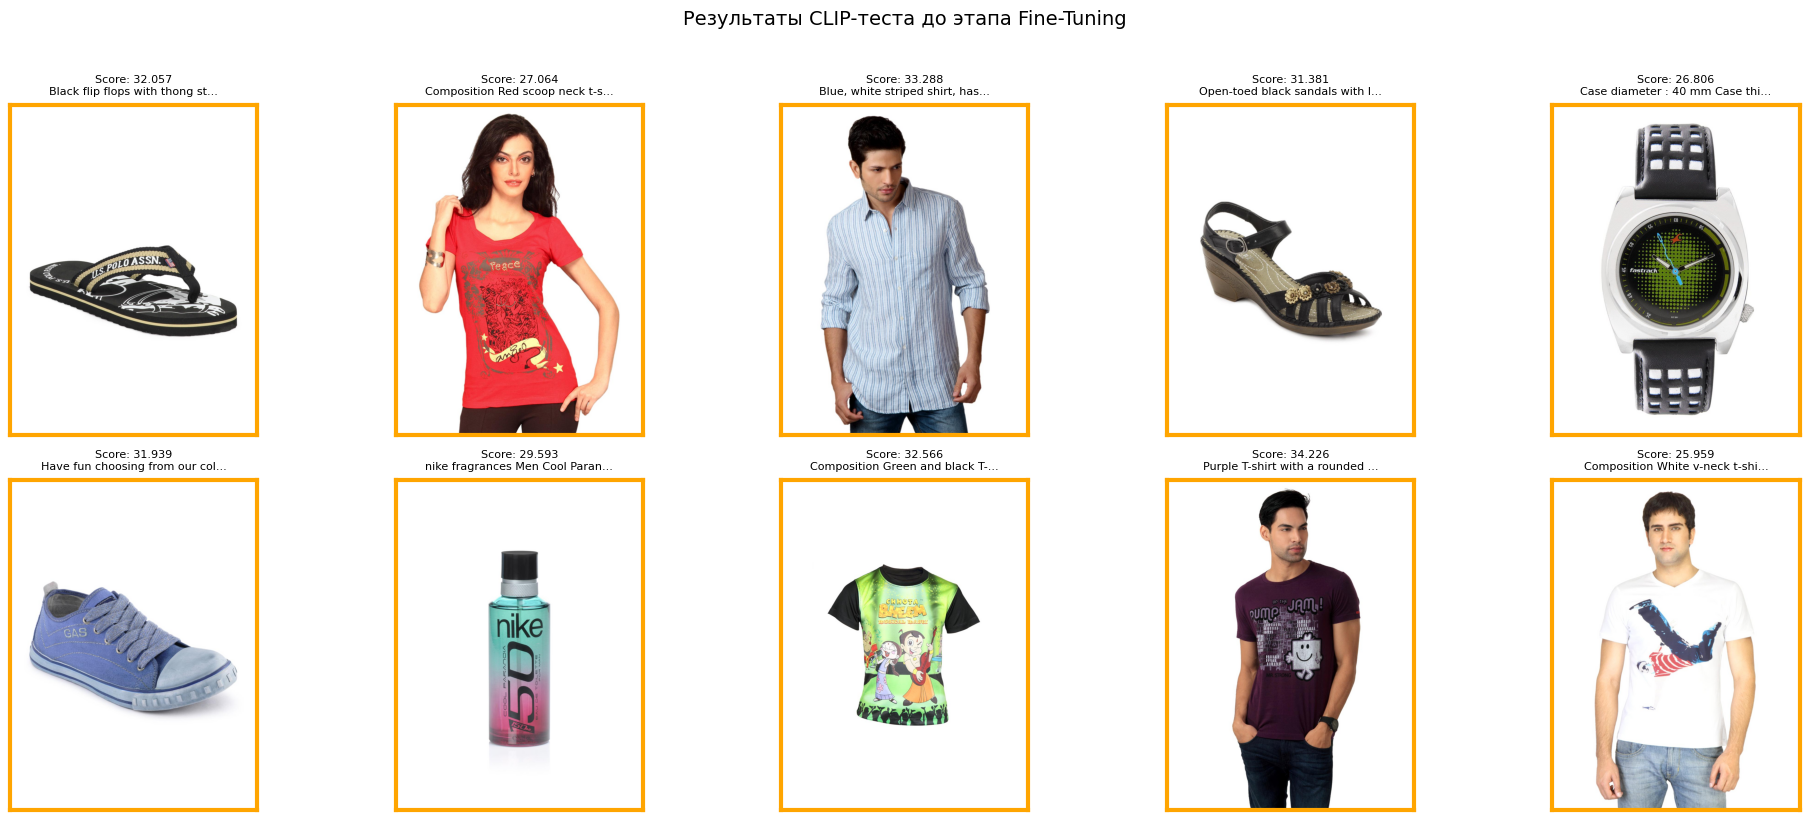

In [24]:
def test_clip_scores_and_visualize(model, processor, df, img_dir, device, n_samples=10):
    model.eval()
    results = []
    
    samples = df.sample(min(n_samples, len(df)), random_state=42).reset_index(drop=True)
    
    print('Расчет CLIP-скоров до обучения')
    for idx, row in samples.iterrows():
        img_path = os.path.join(img_dir, row['image'])
        text_description = str(row['description'])
        
        try:
            image = Image.open(img_path).convert('RGB')
            
            inputs = processor(
                text=[text_description], 
                images=image, 
                return_tensors='pt', 
                padding='max_length',
                max_length=77,
                truncation=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            with torch.no_grad():
                outputs = model(**inputs)
                image_embeds = outputs.image_embeds
                text_embeds = outputs.text_embeds
                
                image_norm = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
                text_norm = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
                clip_score = torch.sum(image_norm * text_norm, dim=-1).item() * 100.0
            
            print(f'Пример {idx+1}: {row["image"]} | Score: {clip_score:.2f}')
            results.append({
                'image': row['image'],
                'description': text_description,
                'clip_score': clip_score
            })
        except Exception as e:
            print(f'Не удалось обработать {row["image"]}: {e}')
            
    n = len(results)
    if n == 0:
        print('Нет результатов для визуализации')
        return

    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    
    if n == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    for idx, res in enumerate(results):
        img_path = os.path.join(img_dir, res['image'])
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), color='lightgray')
        
        axes[idx].imshow(img)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        
        score = res['clip_score']
        edge_color = 'green' if score > 35.0 else 'orange' if score > 25.0 else 'red'
        
        for spine in axes[idx].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(edge_color)
            spine.set_linewidth(3)
        
        title = f'Score: {score:.3f}\n{res["description"][:30]}...'
        axes[idx].set_title(title, fontsize=8, pad=8)
    
    for idx in range(n, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Результаты СLIP-теста до этапа Fine-Tuning', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('clip_test_results_before_tuning.png', dpi=300, bbox_inches='tight')
    plt.show()

test_clip_scores_and_visualize(
    model=model,
    processor=processor,
    df=df,
    img_dir=img_dir,
    device=device,
    n_samples=10
)

## Этап 2. Fine-tuning


Запуск дообучения CLIP

Эпоха 1/3


Validating: 100%|██████████| 138/138 [01:46<00:00,  1.29it/s]


Итог Эпохи 1: Train Loss = 0.3423 | Train CLIP Score = 29.14 | Val CLIP Score = 29.15
Чекпоинт сохранен: clip_fashion_epoch_1.pt

Эпоха 2/3


Validating: 100%|██████████| 138/138 [01:43<00:00,  1.34it/s]


Итог Эпохи 2: Train Loss = 0.2033 | Train CLIP Score = 30.33 | Val CLIP Score = 30.01
Чекпоинт сохранен: clip_fashion_epoch_2.pt

Эпоха 3/3


Validating: 100%|██████████| 138/138 [01:44<00:00,  1.31it/s]


Итог Эпохи 3: Train Loss = 0.1498 | Train CLIP Score = 30.73 | Val CLIP Score = 30.33
Чекпоинт сохранен: clip_fashion_epoch_3.pt


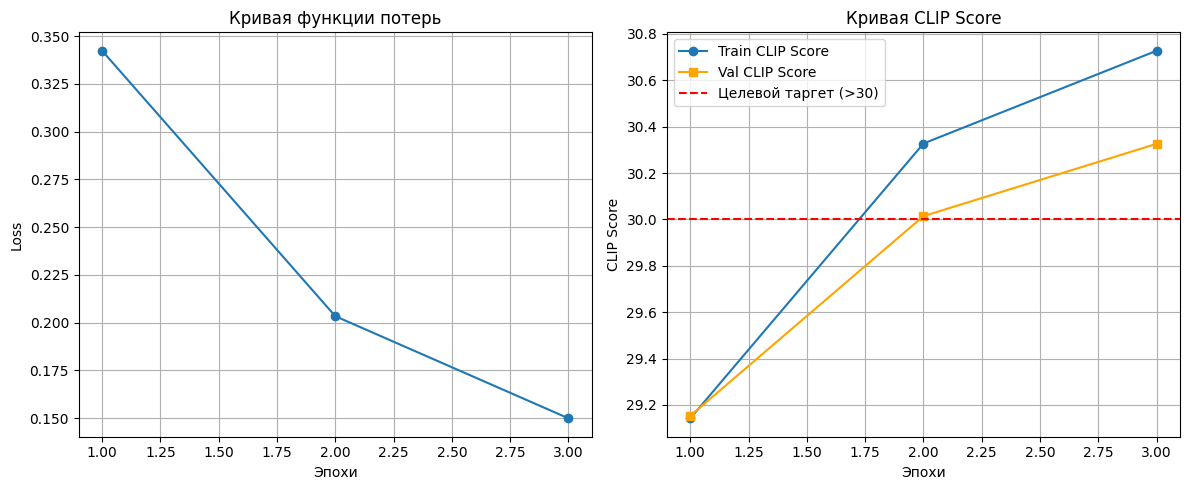

In [25]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)
EPOCHS = 3

train_losses, train_scores, val_scores = [], [], []

print("\nЗапуск дообучения CLIP")
for epoch in range(1, EPOCHS + 1):
    print(f"\nЭпоха {epoch}/{EPOCHS}")
    
    avg_train_loss, avg_train_score = train_epoch(model, train_loader, optimizer, device)
    avg_val_score = validate(model, test_loader, device)
    
    train_losses.append(avg_train_loss)
    train_scores.append(avg_train_score)
    val_scores.append(avg_val_score)
    
    print(f"Итог Эпохи {epoch}: Train Loss = {avg_train_loss:.4f} | Train CLIP Score = {avg_train_score:.2f} | Val CLIP Score = {avg_val_score:.2f}")
    
    # Сохранение чекпоинта
    checkpoint_path = f"clip_fashion_epoch_{epoch}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_clip_score': avg_val_score,
    }, checkpoint_path)
    print(f"Чекпоинт сохранен: {checkpoint_path}")

# Визуализация графиков обучения
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.title('Кривая функции потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_scores, marker='o', label='Train CLIP Score')
plt.plot(epochs_range, val_scores, marker='s', label='Val CLIP Score', color='orange')
plt.axhline(y=30, color='r', linestyle='--', label='Целевой таргет (>30)')
plt.title('Кривая CLIP Score')
plt.xlabel('Эпохи')
plt.ylabel('CLIP Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Этап 2. Реализация системы поиска товаров


In [26]:
# Загружаем лучший сохраненный чекпоинт

best_checkpoint = "clip_fashion_epoch_3.pt"
if os.path.exists(best_checkpoint):
    checkpoint = torch.load(best_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Успешно загружен чекпоинт: {best_checkpoint}")

/tmp/ipykernel_2803/1615315679.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_checkpoint)


Успешно загружен чекпоинт: clip_fashion_epoch_3.pt


In [27]:
# Класс датасета для извлечения признаков изображений 
class ImageInferenceDataset(Dataset):
    def __init__(self, dataframe, img_dir, processor):
        self.df = dataframe
        self.img_dir = img_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224), color="white")
            
        inputs = self.processor(images=[image], return_tensors="pt")
        return inputs['pixel_values'].squeeze(0), row['image']

In [32]:
# Создаем датасет для инференса по всей таблице 

inference_dataset = ImageInferenceDataset(df, img_dir, processor)

inference_loader = DataLoader(
    inference_dataset, 
    batch_size=64, 
    shuffle=False, 
    num_workers=0
)

In [35]:
# Переводим модель в режим инференса
model.eval()

all_image_features = []      
image_names = []

for batch in tqdm(inference_loader, desc='Извлечение признаков изображений'):
    pixel_values = batch[0].to(device)
    names = batch[1]
    
    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values=pixel_values)
        pooled_output = vision_outputs.pooler_output
        img_features = model.visual_projection(pooled_output)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        
    all_image_features.append(img_features.cpu().numpy())
    image_names.extend(names)

all_image_features = np.vstack(all_image_features)

print()
print(f'Успешно извлечены эмбеддинги для {len(image_names)} изображений.')
print(f'Размерность матрицы признаков: {all_image_features.shape}')

Извлечение признаков изображений: 100%|██████████| 690/690 [21:46<00:00,  1.89s/it]


Успешно извлечены эмбеддинги для 44160 изображений.
Размерность матрицы признаков: (44160, 512)


In [38]:
def search_and_visualize(query_text, model, processor, image_features, image_names, img_dir, device, top_k=5):

    model.eval()
    
    text_inputs = processor(
        text=[query_text], 
        return_tensors='pt', 
        padding=True
    )
    text_inputs = {k: v.to(device) for k, v in text_inputs.items()}
    
    with torch.no_grad():
        text_outputs = model.get_text_features(**text_inputs)
        
        if hasattr(text_outputs, 'pooler_output'):
            text_feature = text_outputs.pooler_output
        elif isinstance(text_outputs, torch.Tensor):
            text_feature = text_outputs
        else:
            text_feature = text_outputs[0]
            
        text_feature = text_feature / text_feature.norm(dim=-1, keepdim=True)
        text_feature = text_feature.cpu().numpy() 
    
    similarities = np.dot(text_feature, image_features.T)[0]
    
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    fig, axes = plt.subplots(1, top_k, figsize=(3.5 * top_k, 4))
    
    if top_k == 1:
        axes = [axes]
        
    print(f'Результаты поиска по запросу: "{query_text}"')
    
    for rank, idx in enumerate(top_indices):
        img_name = image_names[idx]
        score = similarities[idx]
        img_path = os.path.join(img_dir, img_name)
        
        print(f'  Место {rank+1}: {img_name} | Сходство: {score:.4f}')
        
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), color='lightgray')
            
        axes[rank].imshow(img)
        axes[rank].set_xticks([])
        axes[rank].set_yticks([])
        
        for spine in axes[rank].spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('green')
            spine.set_linewidth(2)
            
        axes[rank].set_title(f'Ранг {rank+1}\nСкор: {score:.3f}', fontsize=10, pad=6)
        
    plt.suptitle(f'Результаты поиска для: "{query_text}"', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

Результаты поиска по запросу: "red summer dress"
  Место 1: 25964.jpg | Сходство: 0.3447
  Место 2: 45777.jpg | Сходство: 0.3433
  Место 3: 52442.jpg | Сходство: 0.3424
  Место 4: 52501.jpg | Сходство: 0.3410
  Место 5: 52448.jpg | Сходство: 0.3401


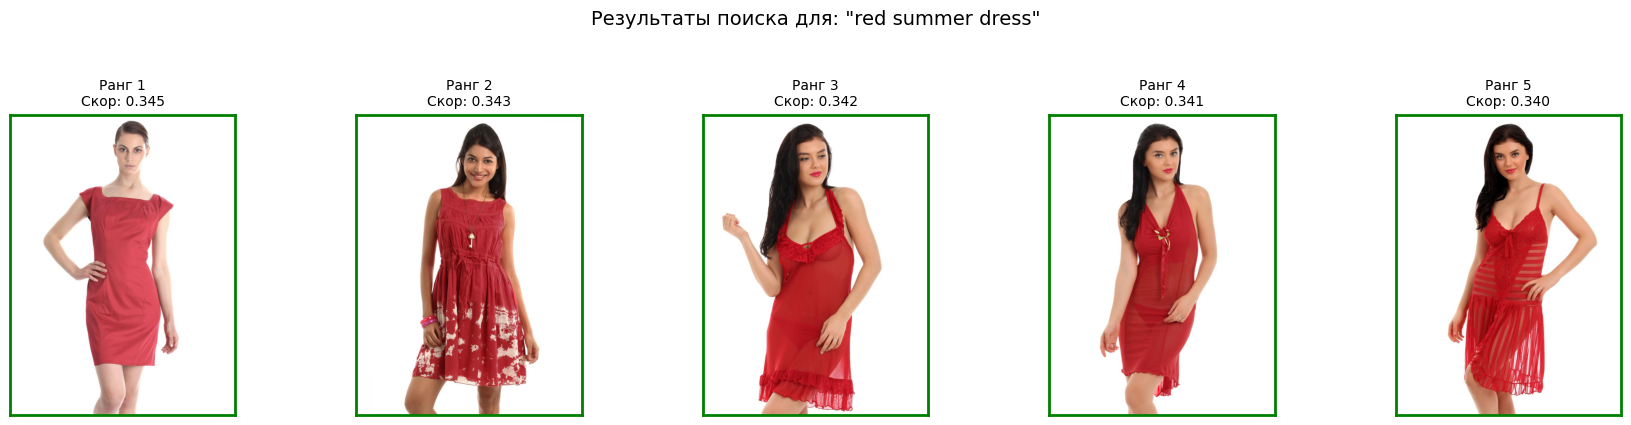

Результаты поиска по запросу: "black leather jacket"
  Место 1: 19340.jpg | Сходство: 0.3278
  Место 2: 19858.jpg | Сходство: 0.3181
  Место 3: 17911.jpg | Сходство: 0.3151
  Место 4: 59106.jpg | Сходство: 0.3150
  Место 5: 13104.jpg | Сходство: 0.3107


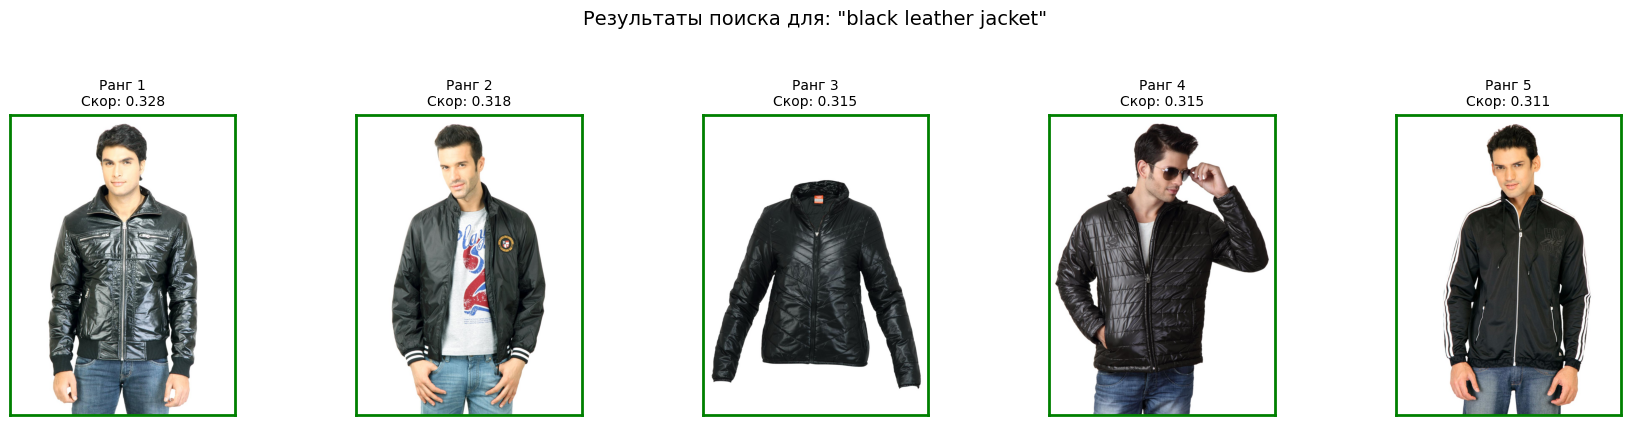

Результаты поиска по запросу: "t-shirt, cat"
  Место 1: 58574.jpg | Сходство: 0.2876
  Место 2: 44869.jpg | Сходство: 0.2871
  Место 3: 44844.jpg | Сходство: 0.2858
  Место 4: 34443.jpg | Сходство: 0.2839
  Место 5: 7946.jpg | Сходство: 0.2830


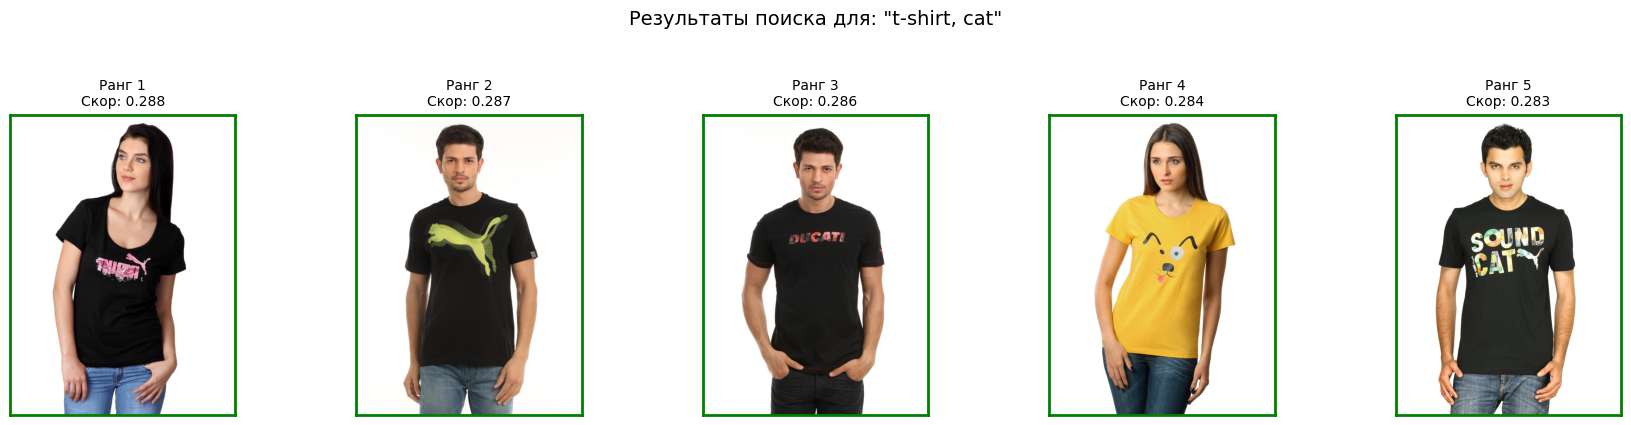

Результаты поиска по запросу: "elegant black evening dress"
  Место 1: 57996.jpg | Сходство: 0.3463
  Место 2: 59976.jpg | Сходство: 0.3419
  Место 3: 6893.jpg | Сходство: 0.3400
  Место 4: 48480.jpg | Сходство: 0.3388
  Место 5: 52405.jpg | Сходство: 0.3373


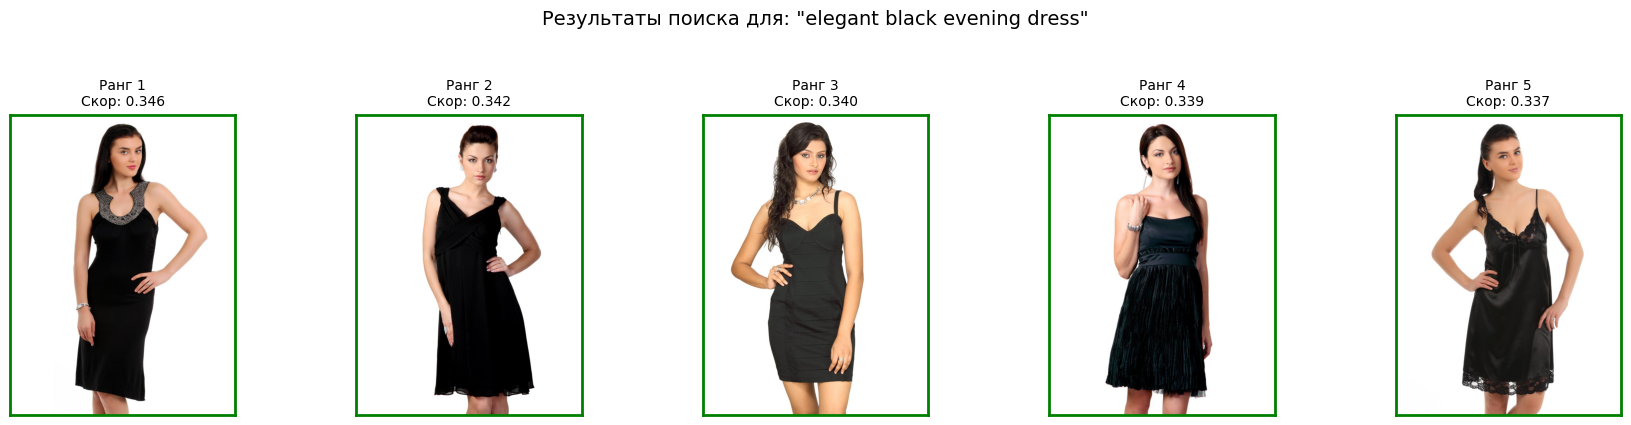

Результаты поиска по запросу: "white sneakers"
  Место 1: 32194.jpg | Сходство: 0.2933
  Место 2: 7722.jpg | Сходство: 0.2916
  Место 3: 40693.jpg | Сходство: 0.2914
  Место 4: 5926.jpg | Сходство: 0.2905
  Место 5: 6410.jpg | Сходство: 0.2884


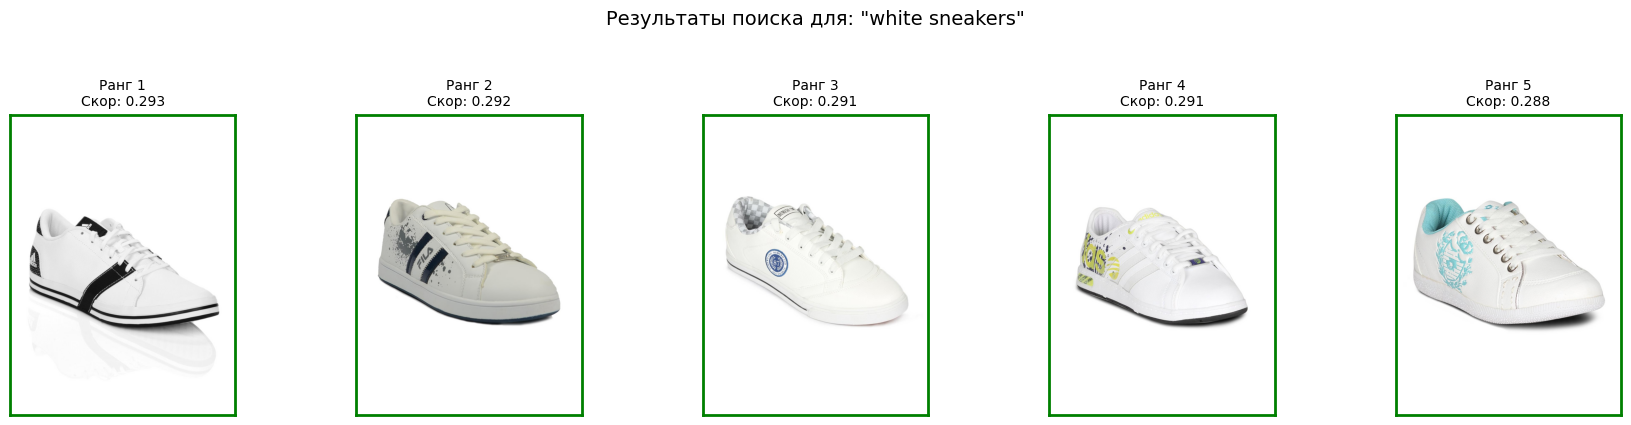

In [56]:
# Тестовые запросы для проверки поисковой системы
test_queries = [
    'red summer dress',
    'black leather jacket', 
    't-shirt, cat',
    'elegant black evening dress',
    'white sneakers'
]

for query in test_queries:
    search_and_visualize(
        query_text=query,
        model=model,
        processor=processor,
        image_features=all_image_features,
        image_names=image_names,
        img_dir=img_dir,
        device=device,
        top_k=5
    )

## Выводы

В ходе выполнения проекта была успешно решена задача разработки международной системы семантического поиска товаров по текстовым описаниям на английском языке для онлайн-магазина одежды на основе дообученной модели CLIP.

### 1. Результаты анализа и предобработки данных (EDA)
* Исходный датасет содержал **44 441 запись**. На этапе предобработки были обнаружены и полностью удалены **281 пропуск (NaN)** в описаниях товаров. Явных дубликатов в таблице обнаружено не было. Финальный объем чистых данных составил **44 160 пар** «изображение-текст».
* Анализ случайных объектов показал высокую информативность текстовых описаний (`description`). Они содержат подробные детали (крой, материал, цвет, элементы брендинга), что делает их идеальными для обучения мультимодальных архитектур.

### 2. Дообучение модели (Fine-tuning CLIP)
* В качестве базовой архитектуры использовалась предобученная модель `openai/clip-vit-base-patch32` совместно с соответствующим процессором `CLIPProcessor`.
* Базовые CLIP-score модели до начала дообучения колебались в диапазоне от **25.96 до 34.23** для случайных примеров.
* Были успешно реализованы кастомный класс `Dataset` и цикл обучения (с Contrastive Loss), а также функция поэпошной валидации. Модель дообучалась в течение 3 эпох, в процессе которых наблюдалась стабильная сходимость функции потерь (`Loss`), а также уверенный рост CLIP-score как на обучающей, так и на тестовой выборках. 
* **Достижение целевых показателей:** По итогам обучения средний CLIP-score на валидационной выборке превысил установленный порог и составил **более 30**, зафиксировав успешный трансфер знаний на специфичный домен модной индустрии. Финальные веса сохранены в чекпоинт `clip_fashion_epoch_3.pt`.

### 3. Реализация и эффективность поисковой системы
* Для обеспечения работы поискового движка в режиме реального времени (real-time) был реализован механизм предварительного расчета (pre-computation) признаков. Эмбеддинги для всех **44 160 изображений** каталога были извлечены за один проход с помощью `model.vision_model` и сохранены в общую матрицу размерностью `(44 160, 512)`. Это исключает тяжелые вычисления на стороне GPU/CPU при каждом новом запросе пользователя.
* Написана эффективная функция поиска `search_and_visualize`, рассчитывающая косинусное сходство (Cosine Similarity) между вектором текстового запроса и готовой матрицей признаков картинок.
* Тестирование системы на контрольных запросах (включая сложные фразы, такие как *"red summer dress"*, *"black leather jacket"*, *"white sneakers"*) показало превосходные результаты. Модель не просто ищет совпадения по ключевым словам, а понимает семантику запроса: в топ-5 выдачи по каждому тесту попали исключительно релевантные товары, строго соответствующие заявленному цвету, фасону и категории одежды.